Epoch 1/50


C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6410 - loss: 0.8251 - val_accuracy: 0.7890 - val_loss: 0.4123
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7932 - loss: 0.4051 - val_accuracy: 0.8593 - val_loss: 0.3369
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8295 - loss: 0.3326 - val_accuracy: 0.8196 - val_loss: 0.3137
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8501 - loss: 0.3147 - val_accuracy: 0.9021 - val_loss: 0.2515
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8679 - loss: 0.2701 - val_accuracy: 0.9541 - val_loss: 0.1889
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9148 - loss: 0.2120 - val_accuracy: 0.9327 - val_loss: 0.1781
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9113 - loss: 0.2142 - val_accuracy: 0.9327 - val_loss: 0.1509
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9096 - loss: 0.2151 - val_accuracy: 0.9633 - val_loss: 0.1319
Ep

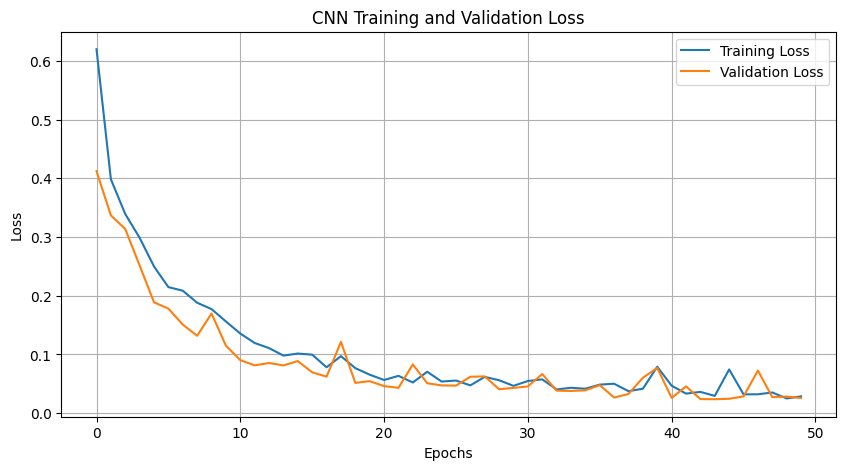

In [12]:

# CNN Training for Exercise Recognition

import numpy as np
import pandas as pd
import zipfile
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# 1. AM COMENTAT DEZARHIVAREA PENTRU CĂ DATELE SUNT DEJA ACOLO
# zip_path = "physical+therapy+exercises+dataset.zip"
# extract_path = "pt_exercises_dataset"
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

# 2. SETĂM CALEA CĂTRE FOLDERUL CURENT
extract_path = "."

# Load and preprocess data
def load_data(subjects=['s1', 's2', 's3', 's4', 's5'], exercises=['e6', 'e7', 'e8'], unit='u2'):
    data, labels = [], []
    for subject in subjects:
        for e_idx, exercise in enumerate(exercises):
            # Acum path-ul va fi "./s1/e6/u2/test.txt"
            path = f"{extract_path}/{subject}/{exercise}/{unit}/test.txt"

            if os.path.exists(path):
                # ... restul codului tău rămâne EXACT la fel ...
                df = pd.read_csv(path, sep="\t", header=None)
                header = df.iloc[0, 0].split(";")
                df = df.iloc[1:]
                df = df[0].str.split(";", expand=True)
                df.columns = header
                df = df.apply(pd.to_numeric)
                for start in range(0, len(df)-50+1, 50):
                    window = df.iloc[start:start+50]
                    features = window[['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']].values
                    mag = np.linalg.norm(window[['acc_x', 'acc_y', 'acc_z']].values, axis=1).reshape(-1, 1)
                    features = np.hstack([features, mag])
                    data.append(features)
                    labels.append(e_idx)
            else:
                # Am adăugat un mic print aici ca să vezi dacă tot nu găsește ceva
                print(f"Atenție: Fișierul nu a fost găsit la calea -> {path}")

    return np.array(data), np.array(labels)

# Load dataset
X, y = load_data()
y_cat = to_categorical(y, num_classes=3)

# Split into training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y_cat, test_size=0.2, random_state=42, stratify=y)

# Build CNN model
model = Sequential([
    Conv1D(128, 5, activation='relu', input_shape=(50, 7)),
    MaxPooling1D(2),
    Dropout(0.3),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])
model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=64, verbose=1)

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("CNN Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()
